# **Time-Series Forecasting of Agricultural Production**


The project aims to forecast agricultural production using historical time-series data obtained from the food Agriculture organisation corpotate statistical Database (FAOSTAT) maintained by the Food and Agriculture Organization (FAO) of the United Nations.

The dataset provides long-term, publicly available agricultural production statistics at country and crop level.

The project is to clearly define the research objective. The study will focus on forecasting the future production of a selected crop in a specific country using historical production data. This focused scope ensures that the analysis remains manageable and suitable for time-series modelling.

The dataset will be explored to understand its structure and key variables. Important fields include the country (Area), crop type (Item), production measure (Element), year, and production value. Understanding these variables is essential to correctly construct the time series.

1. Import Required Libraries:

Explanation:

We import libraries for data handling, plotting, statistical tests, time-series models, machine learning metrics, and deep learning.

In [ ]:
import pandas as pd # this data frame used for reading, filtering, and reshaping tabular data
import numpy as np # numerical operations
import matplotlib.pyplot as plt # used for plotting the time series
import matplotlib.ticker as ticker
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

2. Loading the FAOSTAT Dataset

Explanation:

We load the original FAOSTAT CSV file into a pandas DataFrame.

In [ ]:
# storing the location of your CSV file
file_path = "Production_Crops_Livestock_E_All_Data.csv"
df = pd.read_csv(file_path)
df.head()

/tmp/ipykernel_798/501396160.py:3: DtypeWarning: Columns (11,14,17,20,23,26,29,32,35,38,41,44,47,50,53,56,59,62,65,68,71,74,77,80,83,86,89,92,95,98,101,104,107,110,113,116,119,122,125,128,131,134,137,140,143,146,149,152,155,158,161,164,167,170,173,176,179,182,185,188,191,194,197,200) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
0,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5312,Area harvested,ha,0.0,...,NaN,36462.0,A,NaN,37000.0,A,NaN,39794.00,I,NaN
1,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5412,Yield,kg/ha,NaN,...,NaN,1742.0,A,NaN,1810.8,A,NaN,1741.90,E,NaN
2,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,0.0,...,NaN,63515.0,A,NaN,67000.0,A,NaN,69315.64,I,NaN
3,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,ha,NaN,...,NaN,25403.0,E,NaN,25439.0,E,NaN,25400.00,E,NaN
4,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5412,Yield,kg/ha,NaN,...,NaN,704.0,E,NaN,704.0,E,NaN,704.30,E,NaN


3. Filter Dataset (Country, Crop, Production)

Explanation:

We select:

	One country
	One crop
	Production values only
  
Creates a clean univariate time series.

In [ ]:
#countries = ["India","United Kindom","United States of America"]
country = "India"
crop = "Wheat"
df_filtered = df[
    (df["Area"] == country) &
    #(df["Area"].isin(countries))&
    (df["Item"] == crop) &
    (df["Element"] == "Production")]
df_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
25786,100,'356,India,15,'0111,Wheat,5510,Production,t,10997000.0,...,NaN,107742070.0,A,NaN,1.105537e+08,A,NaN,113292368.0,A,NaN


In [ ]:
Unit = df_filtered["Unit"].iloc[0]

4. Data Cleaning

Explanation:

Removing missing values and ensure production values are positive.

In [ ]:
year_columns = [col for col in df_filtered.columns if col.startswith("Y")]
ts = df_filtered[year_columns].T
ts.index = [int(''.join(filter(str.isdigit, year))) for year in year_columns]
ts.columns = ["Production"]
ts.head()

,Production
1961,10997000.0
1961,A
1961,NaN
1962,12072000.0
1962,A


5. Converting to Time Series Format

Explanation:

We convert Year into a datetime index, which is required for time-series models.

In [ ]:
# The 'Year' column has already been converted to a datetime index in the previous step.
# Therefore, the following two lines are redundant and cause a KeyError.
ts["Production"] = pd.to_numeric(ts["Production"],errors="coerce")

# Removing missing values
ts = ts.dropna()

# Removing zero or negative values
ts = ts[ts["Production"] > 0]

# Converting to datetime
ts.index = pd.to_datetime(ts.index, format="%Y")

# Sorting chronologically
ts = ts.sort_index()
print("Cleaned Data Preview:")
print(ts.head())
print("Total Observations:", len(ts))


Cleaned Data Preview:
            Production
1961-01-01  10997000.0
1962-01-01  12072000.0
1963-01-01  10776000.0
1964-01-01   9853000.0
1965-01-01  12257000.0
Total Observations: 64


6. Exploratory Data Analysis (EDA)

Plotting the Time Series

Explanation:

This shows long-term production trends.

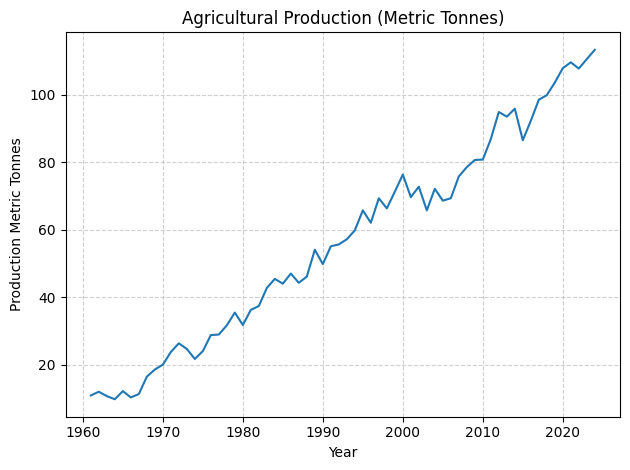

In [ ]:
# plotting the EDA
ts["Production_Million"] = ts["Production"]/1000000
plt.figure()
plt.plot(ts.index, ts["Production_Million"])
plt.title("Agricultural Production (Metric Tonnes)")
plt.xlabel("Year")
plt.ylabel("Production Metric Tonnes")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

7. Training and Testing data

Training data is used to teach the model and estimate parameters

*   it trains past data

Testing data is used to evaluate the model's performance on unseen data to ensure it generatizes well.

*   it tests future data

 Models may memorize, gives fake high accuracy, called Overfitting.


In [ ]:
#Training-testing(80% train, 20% test)
#Spliting the data into 80% training and 20% testing
train_size = int(len(ts) * 0.8)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 51
Test size: 13


**8**. Baseline model/ Naïve forecasting:

It provides a benchmark to ensure that advanced models genuinely improve forecasting performance beyond simple presistence assumptions.

This models can called as Naïve forecasting

In [ ]:
#Naïve forecasting/ baseline forcating
#Taking last value from training data
#Repeating it for length of test period
baseline_forecast = np.repeat(train["Production"].iloc[-1],len(test))

#Storing the results in DataFrame
baseline_df = pd.DataFrame({
    "Actual": test["Production"],
    "Baseline Forecast": baseline_forecast}, index=test.index)

**Ploting Basline model:**

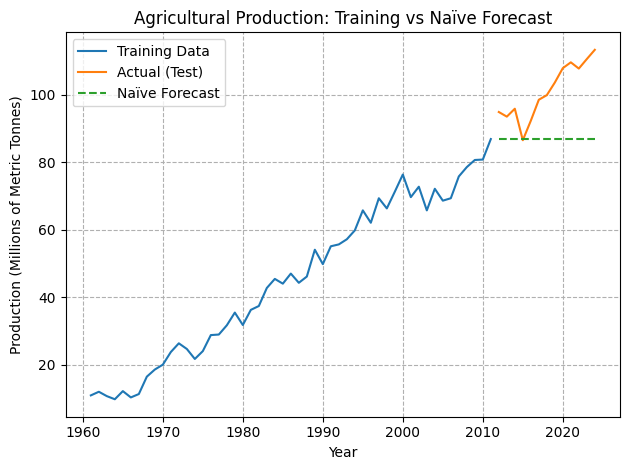

In [ ]:
# plotting the Training, Actual, and Baseline /Naïve Forecasting
plt.figure()
plt.plot(train.index, train["Production"] / 1000000, label="Training Data")
plt.plot(test.index, test["Production"] / 1000000, label="Actual (Test)")
plt.plot(test.index, baseline_forecast / 1000000, label="Naïve Forecast",linestyle="--")
plt.title("Agricultural Production: Training vs Naïve Forecast")
plt.xlabel("Year")
plt.ylabel("Production (Millions of Metric Tonnes)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

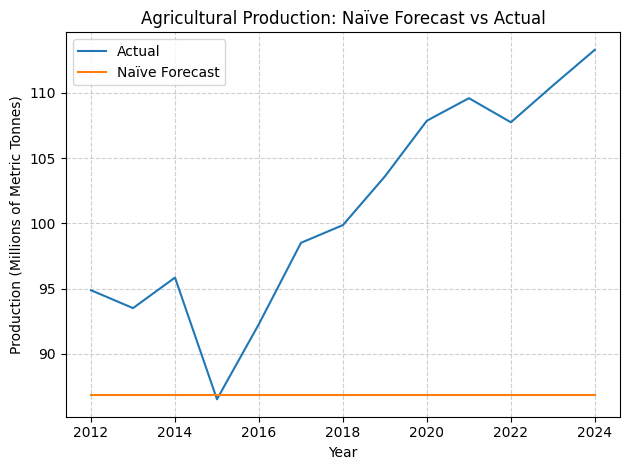

In [ ]:
# plotting the Naïve forecasting
plt.figure()
plt.plot(baseline_df.index, baseline_df["Actual"] / 1000000, label="Actual")
plt.plot(baseline_df.index, baseline_df["Baseline Forecast"] / 1000000, label="Naïve Forecast")
plt.title("Agricultural Production: Naïve Forecast vs Actual")
plt.xlabel("Year")
plt.ylabel("Production (Millions of Metric Tonnes)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

**9**. AutoRegressive intergrated Moving Average (ARIMA) Model:


The AutoRegressive Integrated Moving Average (ARIMA) model is a widely used statistical method for time-series forecasting. ARIMA models analyse historical observations and use them to predict future values by capturing linear dependencies within the data. The model consists of three main components: autoregression (AR), differencing (I), and moving average (MA).

The autoregressive component represents the relationship between the current observation and previous observations in the series. The integrated component refers to differencing, which is applied to transform non-stationary data into a stationary form. The moving average component models the relationship between the observation and past forecast errors.

The ARIMA model is typically expressed as ARIMA(p, d, q), where:

*   p represents the number of autoregressive terms.
*   d represents the degree of differencing required to achieve stationarity.
*   q represents the number of moving average terms.


In [ ]:
#ADF Test: its Augmented Dickey–Fuller (ADF) test is used in time-series analysis to
#check whether the data is stationary. Stationarity is important because models like
#ARIMA require the time series to have a constant mean and variance over time.
result = adfuller(ts["Production"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ts_diff = ts["Production"].diff().dropna()
result_diff = adfuller(ts_diff)
print("ADF Statistic after differencing:", result_diff[0])
print("p-value after differencing:", result_diff[1])

ADF Statistic: 0.5223189974863071
p-value: 0.9855359074951656
ADF Statistic after differencing: -11.270068162289286
p-value after differencing: 1.5447308923906597e-20


1. ACF (Autocorrelation Function)

ACF measures the correlation between the time series and its lagged values.

Example:

Lag 1 → relationship between current year and previous year

Lag 2 → relationship between current year and two years before

ACF helps determine the q parameter of ARIMA.

2. PACF (Partial Autocorrelation Function)

PACF measures the direct relationship between a variable and its lag after removing intermediate lags.

PACF helps determine the p parameter of ARIMA.

<Figure size 1000x400 with 0 Axes>

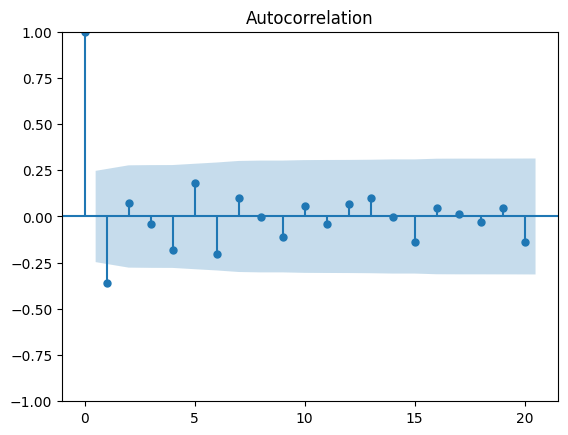

<Figure size 1000x400 with 0 Axes>

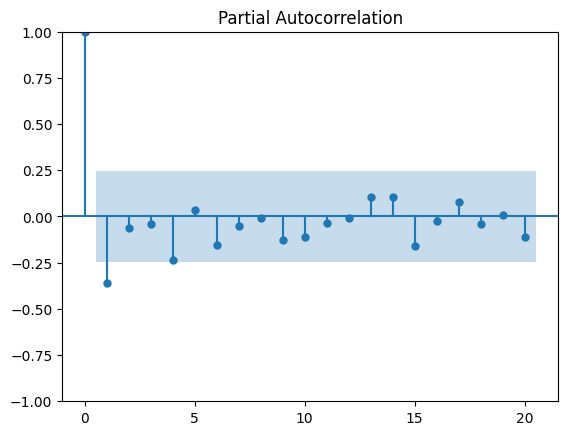

In [ ]:
# ACF and PACF Plotings
#These plots to decide p and q
plt.figure(figsize=(10,4))
plot_acf(ts_diff, lags=20)
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(ts_diff, lags=20)
plt.show()

In [ ]:
model = ARIMA(train["Production"], order=(1,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))
forecast_million = forecast / 1_000_000

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


ARIMA Model Plotting and ACTUAL Plotting:

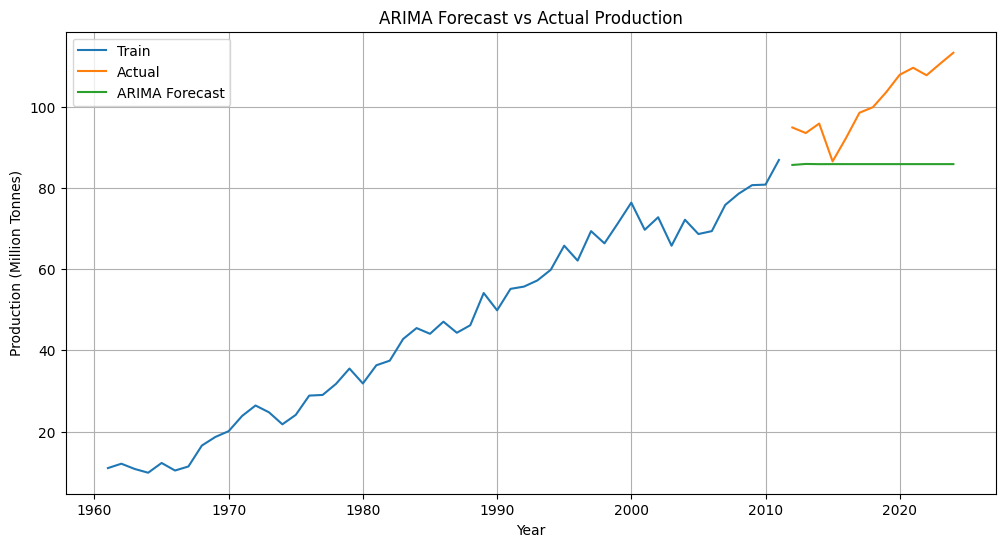

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train["Production_Million"], label="Train")
plt.plot(test.index, test["Production_Million"], label="Actual")
plt.plot(test.index, forecast_million, label="ARIMA Forecast")

plt.title("ARIMA Forecast vs Actual Production")
plt.xlabel("Year")
plt.ylabel("Production (Million Tonnes)")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.grid(True)

plt.show()

**10**. Long Short-Term Memory (LSTM) Model:

Long Short-Term Memory (LSTM) is a type of recurrent neural network (RNN) designed for modelling sequential and time-series data. Unlike traditional neural networks, LSTM networks can capture long-term dependencies within a sequence by maintaining information over extended time intervals.

LSTM networks contain specialised memory cells and gating mechanisms that regulate the flow of information. These gates include the input gate, forget gate, and output gate, which allow the network to selectively retain or discard information from previous time steps. This architecture enables LSTM models to learn complex nonlinear patterns in temporal data.

The LSTM model is particularly useful for time-series forecasting tasks where patterns may be nonlinear or difficult to capture using traditional statistical methods.

In [ ]:
# The data were normalised using a MinMaxScaler to ensure stable training
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[["Production"]])
test_scaled = scaler.transform(test[["Production"]])

In [ ]:
def create_dataset(data, time_step=3):
    X = []
    y = []
    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step),0])
        y.append(data[i+time_step,0])
    return np.array(X), np.array(y)

In [ ]:
# compare the previous years
time_step = 3
X_train, y_train = create_dataset(train_scaled, time_step)
X_test, y_test = create_dataset(test_scaled, time_step)

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(time_step,1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=50, verbose=1)
predictions = model_lstm.predict(X_test)
predictions = scaler.inverse_transform(predictions)
pred_million = predictions.flatten() / 1_000_000

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 818ms/step - loss: 0.2907
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2775
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2648
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2518
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2389
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2262
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2142
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2015
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1894
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1780
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1648
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1539
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1421
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1303
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1188 
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33m

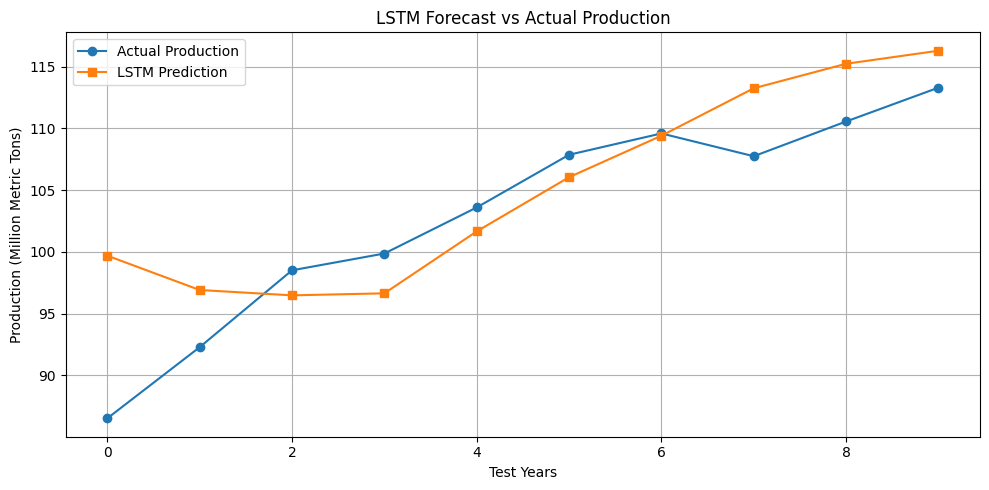

In [ ]:
# Convert actual test values
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
actual_million = y_test_actual.flatten() / 1_000_000

plt.figure(figsize=(10,5))

plt.plot(actual_million, label="Actual Production", marker='o')
plt.plot(pred_million, label="LSTM Prediction", marker='s')

plt.title("LSTM Forecast vs Actual Production")
plt.xlabel("Test Years")
plt.ylabel("Production (Million Metric Tons)")

plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

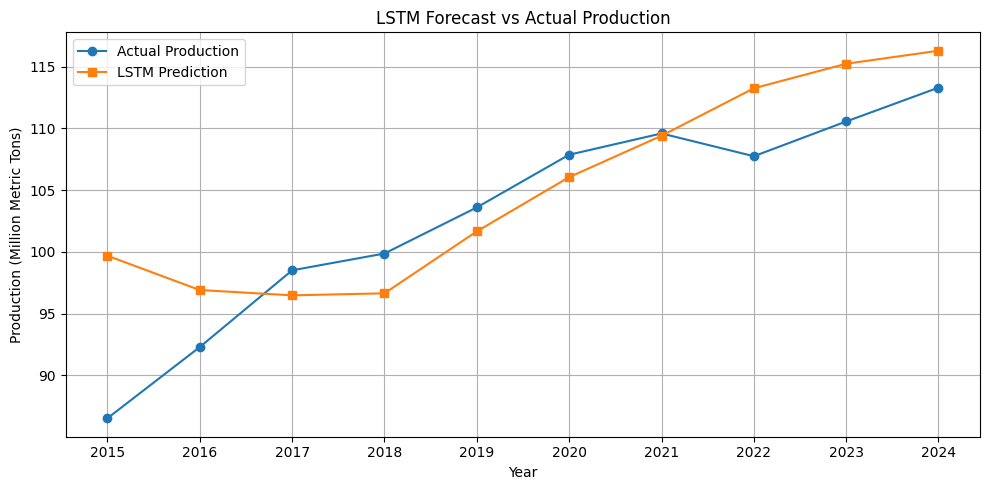

In [ ]:
# Getting years matching prediction length
test_years = test.index[-len(y_test):]

# Convert scaled values back to original values
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
actual_million = y_test_actual.flatten() / 1_000_000
plt.figure(figsize=(10,5))
plt.plot(test_years, actual_million, label="Actual Production", marker='o')
plt.plot(test_years, pred_million, label="LSTM Prediction", marker='s')
plt.title("LSTM Forecast vs Actual Production")
plt.xlabel("Year")
plt.ylabel("Production (Million Metric Tons)")
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
# -------- Baseline --------
baseline_rmse = np.sqrt(mean_squared_error(test["Production"], baseline_forecast))
baseline_mape = np.mean(np.abs((test["Production"] - baseline_forecast) / test["Production"])) * 100
baseline_mae = mean_absolute_error(test["Production"], baseline_forecast)

# -------- ARIMA --------
arima_rmse = np.sqrt(mean_squared_error(test["Production"], forecast))
arima_mape = np.mean(np.abs((test["Production"] - forecast) / test["Production"])) * 100
arima_mae = mean_absolute_error(test["Production"], forecast)

# -------- LSTM --------
actual_lstm = test["Production"].values[:len(predictions)]
lstm_rmse = np.sqrt(mean_squared_error(actual_lstm, predictions))
actual_lstm = test["Production"].values[:len(predictions)]

lstm_mape = np.mean(np.abs((actual_lstm - predictions) / actual_lstm)) * 100
lstm_mae = mean_absolute_error(actual_lstm, predictions)

# -------- Printing Results --------
print("Baseline RMSE:", baseline_rmse)
print("Baseline MAPE:", baseline_mape)
print("Baseline MAE:", baseline_mae)
print()
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)
print("ARIMA MAE:", arima_mae)
print()
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)
print("LSTM MAE:", lstm_mae)

Baseline RMSE: 16296520.219541792
Baseline MAPE: 13.570834549223118
Baseline MAE: 14261314.870000001

ARIMA RMSE: 17197867.650088787
ARIMA MAPE: 14.536064084660746
ARIMA MAE: 15238635.41290782

LSTM RMSE: 7516858.694611041
LSTM MAPE: 10.390174302043361
LSTM MAE: 6910990.0


In [ ]:
results = pd.DataFrame({

"Model":["Baseline","ARIMA","LSTM"],

"RMSE":[baseline_rmse, arima_rmse, lstm_rmse],
"MAPE":[baseline_mape, arima_mape, lstm_mape],
"MAE":[baseline_mae, arima_mae, lstm_mae]

})

print(results)

      Model          RMSE       MAPE           MAE
0  Baseline  1.629652e+07  13.570835  1.426131e+07
1     ARIMA  1.719787e+07  14.536064  1.523864e+07
2      LSTM  7.516859e+06  10.390174  6.910990e+06


      Model       RMSE
0  Baseline  16.296520
1     ARIMA  17.197868
2      LSTM   7.516859


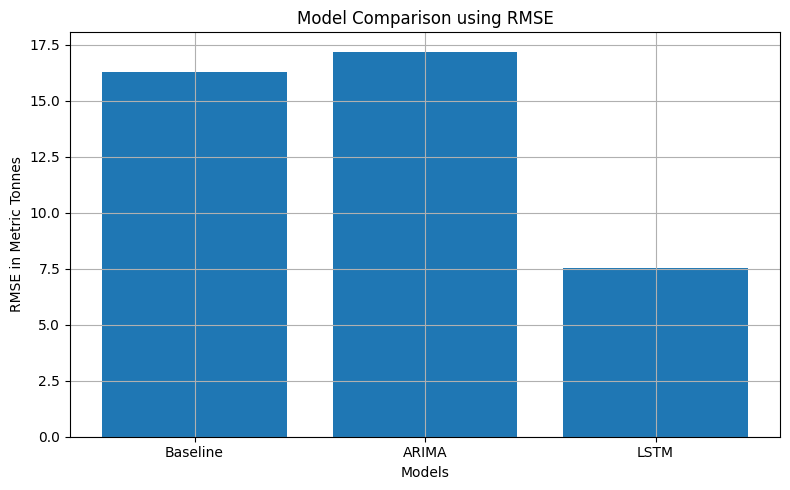

In [ ]:
# Creating results dataframe of Root Mean Square Error
results = pd.DataFrame({
    "Model": ["Baseline", "ARIMA", "LSTM"],
    "RMSE": [baseline_rmse/1000000, arima_rmse/1000000, lstm_rmse/1000000]
})

print(results)

# Plot
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison using RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE in Metric Tonnes")

plt.grid()
plt.tight_layout()

plt.show()

      Model       MAPE
0  Baseline  13.570835
1     ARIMA  14.536064
2      LSTM  10.390174


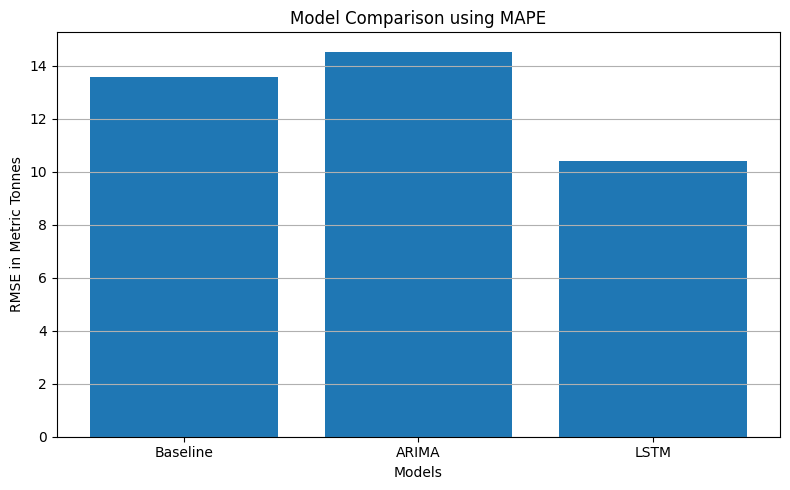

In [ ]:
# Creating results dataframe of Mean Absolute Percentage Error
results = pd.DataFrame({
    "Model": ["Baseline", "ARIMA", "LSTM"],
    "MAPE": [baseline_mape, arima_mape, lstm_mape]
})

print(results)

# Plot
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["MAPE"])


plt.title("Model Comparison using MAPE")
plt.xlabel("Models")
plt.ylabel("RMSE in Metric Tonnes")

plt.grid(axis='y')
plt.tight_layout()

plt.show()

      Model        MAE
0  Baseline  14.261315
1     ARIMA  15.238635
2      LSTM   6.910990


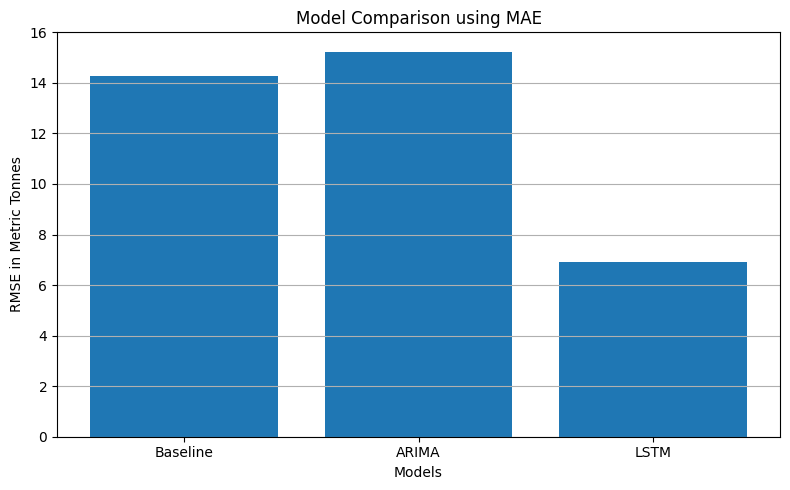

In [ ]:
# Creating results dataframe Mean absolute Error
results = pd.DataFrame({
    "Model": ["Baseline", "ARIMA", "LSTM"],
    "MAE": [baseline_mae/1000000, arima_mae/1000000, lstm_mae/1000000]
})

print(results)

# Plot
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["MAE"])

plt.title("Model Comparison using MAE")
plt.xlabel("Models")
plt.ylabel("RMSE in Metric Tonnes")

plt.grid(axis='y')
plt.tight_layout()

plt.show()

Hyper parameter Tuning


In [ ]:
# Hyperparameter tuning for ARIMA
p_values = [0, 2]
d_values = [0, 1]
q_values = [0, 2]

best_score = float("inf")
best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train["Production"], order=(p, d, q))
                model_fit = model.fit()

                forecast = model_fit.forecast(steps=len(test))

                rmse = np.sqrt(mean_squared_error(test["Production"], forecast))
                # mape = np.mean(np.abs((test["Production"] - forecast) / test["Production"])) * 100

                print(f"ARIMA({p},{d},{q}) RMSE: {rmse}")

                if rmse < best_score:
                    best_score = rmse
                    best_order = (p, d, q)

            except:
                continue

print("\nBest ARIMA Order:", best_order)
print("Best RMSE:", best_score)
#print("Best MAPE:", best_mape)

ARIMA(0,0,0) RMSE: 56189030.534915805
ARIMA(0,0,2) RMSE: 54008794.86774308


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

ARIMA(0,1,0) RMSE: 16296520.219541792
ARIMA(0,1,2) RMSE: 16316707.69835072
ARIMA(2,0,0) RMSE: 18511098.78817562
ARIMA(2,0,2) RMSE: 18280520.946321823
ARIMA(2,1,0) RMSE: 16062637.461395822
ARIMA(2,1,2) RMSE: 6563629.880238358

Best ARIMA Order: (2, 1, 2)
Best RMSE: 6563629.880238358


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [ ]:
neurons_list = [20, 50, 100]
epochs_list = [20, 50]
batch_sizes = [1, 4]

best_rmse = float("inf")
best_params = None

for neurons in neurons_list:
    for epochs in epochs_list:
        for batch in batch_sizes:

            model = Sequential()
            model.add(LSTM(neurons, input_shape=(time_step,1)))
            model.add(Dense(1))

            model.compile(optimizer='adam', loss='mse')

            model.fit(X_train, y_train, epochs=epochs, batch_size=batch, verbose=0)

            pred = model.predict(X_test)
            pred = scaler.inverse_transform(pred)

            rmse = np.sqrt(mean_squared_error(y_test_actual, pred))

            print(f"Neurons:{neurons}, Epochs:{epochs}, Batch:{batch} → RMSE:{rmse}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = (neurons, epochs, batch)

print("\nBest LSTM Parameters:", best_params)
print("Best RMSE:", best_rmse)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Neurons:20, Epochs:20, Batch:1 → RMSE:5542530.584794391


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Neurons:20, Epochs:20, Batch:4 → RMSE:4855009.582316575


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Neurons:100, Epochs:20, Batch:4 → RMSE:6416432.882987377


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Neurons:100, Epochs:50, Batch:1 → RMSE:5203849.975720432


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Neurons:100, Epochs:50, Batch:4 → RMSE:4943580.137966136

Best LSTM Parameters: (20, 20, 4)
Best RMSE: 4855009.582316575
